<a href="https://colab.research.google.com/github/DevBatra05/PVR_Sem-6/blob/main/Exp-06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Google Colab Link :- https://colab.research.google.com/github/DevBatra05/PVR_Sem-6/blob/main/Exp-06.ipynb#scrollTo=7UnUQvO9W-a1

# Experiment No. 6
## Semantic Segmentation using Deep Learning — FCN (Fully Convolutional Network)

---

### Aim
To understand and implement **Semantic Segmentation** using a **Fully Convolutional Network (FCN)** — first from scratch using NumPy to understand the core concepts, then using TensorFlow/Keras for a complete trainable pipeline on the MNIST dataset.

---

### Theory

#### What is Semantic Segmentation?
Semantic segmentation is a deep learning task where the goal is to **assign a class label to every single pixel** in an image — rather than just classifying the whole image.

For example, in an image of a digit:
- Pixels belonging to the digit → Class 1 (foreground)
- Pixels belonging to the background → Class 0 (background)

The output is a **segmentation mask** — an image of the same size as the input, where each pixel value is its predicted class.

---

#### What is a Fully Convolutional Network (FCN)?
A standard CNN ends with **Fully Connected (Dense) layers** that produce a single class label for the whole image. This loses all spatial information.

An **FCN replaces all Dense layers with Convolutional layers**, so the network can produce a **spatial output map** of the same size as the input.

The FCN has two main parts:

**Encoder (Downsampling path):**
- Applies Convolution + ReLU to extract features
- Applies MaxPooling to reduce spatial size
- The network learns what features are present and where

**Decoder (Upsampling path):**
- Applies Upsampling to restore spatial size back to the original
- Applies Convolution to refine the feature maps
- Final 1x1 Convolution with Sigmoid gives a pixel-wise probability map

---

#### Key Operations

**Convolution:**
A filter (kernel) slides over the image. At each position, the element-wise product of the kernel and the image patch is summed to produce one output value.

**Output size after convolution:**
output_size = input_size - kernel_size + 1

**ReLU (Rectified Linear Unit):**
ReLU(x) = max(0, x)
Removes negative values, introducing non-linearity.

**Max Pooling:**
Divides the feature map into non-overlapping 2x2 blocks and keeps only the maximum value from each block. This reduces spatial size by half and makes the network translation-invariant.

**Upsampling (Nearest Neighbour):**
The reverse of pooling — each pixel is repeated in a 2x2 block to double the spatial size. This restores the output to the original image dimensions.

**Pixel-wise Binary Cross-Entropy Loss:**
Since every pixel is independently classified as 0 or 1, we use Binary Cross-Entropy averaged over all pixels:

J = -(1/N) * sum [ y * log(p) + (1-y) * log(1-p) ]

Where y is the ground truth mask pixel and p is the predicted probability.

---

#### FCN vs Standard CNN

| Property | Standard CNN | FCN |
|---|---|---|
| Output | Single class label | Pixel-wise class map |
| Final layers | Dense (Fully Connected) | 1x1 Convolution |
| Spatial info preserved | No | Yes |
| Task | Image Classification | Semantic Segmentation |

---
## Part A: FCN Pipeline from Scratch (No Training — Concept Demo)

We walk through the FCN pipeline step by step on a single MNIST image using NumPy only.

Each step is visualized so we can see exactly what the network does at each stage:
1. Load and display one MNIST digit image
2. Apply Convolution with a hand-crafted kernel
3. Apply ReLU activation
4. Apply Max Pooling (downsampling)
5. Apply a second Convolution
6. Apply Upsampling (restore size)
7. Resize to original 28x28
8. Threshold to produce a binary segmentation mask

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


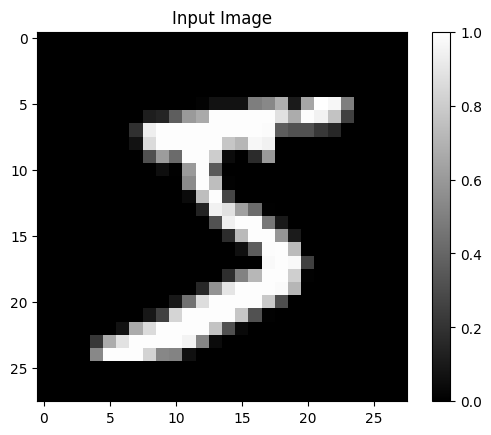

Shape: (28, 28)


In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist  # MNIST handwritten digits dataset

# Load MNIST dataset — we only need training images for this demo
(train_images, train_labels), _ = mnist.load_data()

# Take the first image and normalize pixel values from [0,255] to [0,1]
image = train_images[0] / 255.0

# Display the raw input image
plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.colorbar()
plt.show()

# Print the shape — MNIST images are 28x28 pixels, single channel
print("Shape:", image.shape)

In [ ]:
def convolve(image, kernel):
    """
    Applies a 2D convolution on a grayscale image using a given kernel.
    No padding is used — output is smaller than input.
    Output size = (input_h - kernel_size + 1, input_w - kernel_size + 1)
    """
    h, w = image.shape
    k    = kernel.shape[0]

    # Output feature map — smaller than input due to no padding
    output = np.zeros((h - k + 1, w - k + 1))

    for i in range(h - k + 1):
        for j in range(w - k + 1):
            # Extract patch of same size as kernel
            patch = image[i:i+k, j:j+k]

            # Element-wise multiply and sum = one output value
            output[i, j] = np.sum(patch * kernel)

    return output

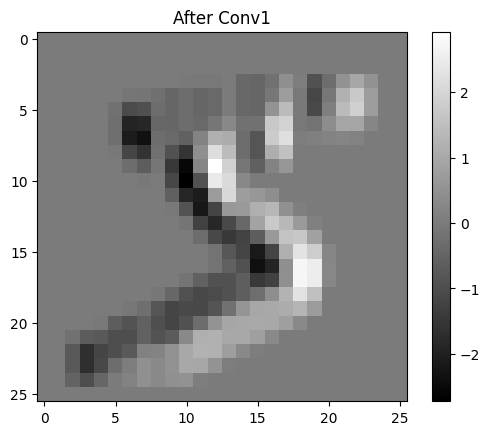

Shape after Conv1: (26, 26)


In [ ]:
# Vertical edge detector kernel — detects left-to-right intensity changes
kernel1 = np.array([
    [ 1,  0, -1],
    [ 1,  0, -1],
    [ 1,  0, -1]
])

# Apply first convolution — extracts vertical edge features
conv1 = convolve(image, kernel1)

plt.imshow(conv1, cmap='gray')
plt.title("After Conv1")
plt.colorbar()
plt.show()

# Output is slightly smaller: 28-3+1 = 26x26
print("Shape after Conv1:", conv1.shape)

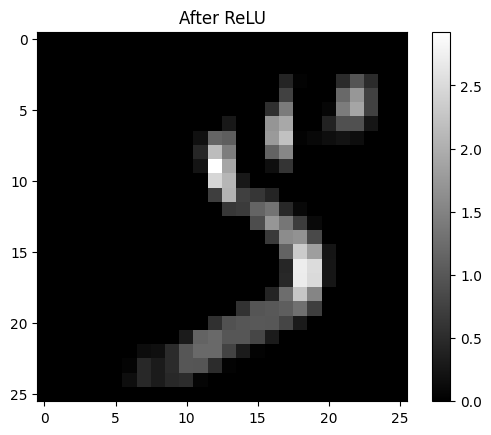

In [ ]:
# Apply ReLU — set all negative values to 0
# Negative values in a feature map have no meaning (no edge detected)
# ReLU introduces non-linearity — essential for deep learning
relu1 = np.maximum(0, conv1)

plt.imshow(relu1, cmap='gray')
plt.title("After ReLU")
plt.colorbar()
plt.show()

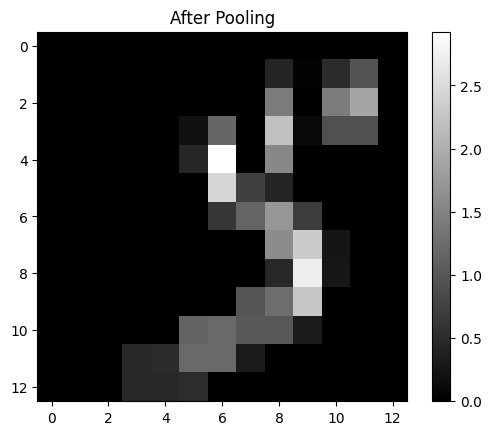

Shape after pooling: (13, 13)


In [ ]:
def max_pool(image):
    """
    Applies 2x2 Max Pooling with stride 2.
    Takes the maximum value in each 2x2 non-overlapping block.
    Reduces spatial dimensions by half — 26x26 becomes 13x13.
    """
    h, w   = image.shape
    output = np.zeros((h // 2, w // 2))

    for i in range(0, h, 2):
        for j in range(0, w, 2):
            # 2x2 patch
            patch = image[i:i+2, j:j+2]
            # Keep only the strongest activation
            output[i//2, j//2] = np.max(patch)

    return output

pool1 = max_pool(relu1)

plt.imshow(pool1, cmap='gray')
plt.title("After Pooling")
plt.colorbar()
plt.show()

# Size is halved: 26x26 -> 13x13
print("Shape after pooling:", pool1.shape)

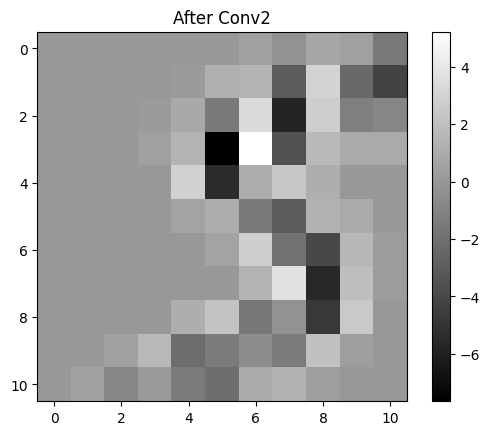

Shape after Conv2: (11, 11)


In [ ]:
# Laplacian kernel — detects edges in all directions (blob detector)
# Highlights regions where intensity changes sharply in any direction
kernel2 = np.array([
    [ 0,  1,  0],
    [ 1, -4,  1],
    [ 0,  1,  0]
])

# Apply second convolution on pooled feature map
conv2 = convolve(pool1, kernel2)

plt.imshow(conv2, cmap='gray')
plt.title("After Conv2")
plt.colorbar()
plt.show()

# 13-3+1 = 11x11
print("Shape after Conv2:", conv2.shape)

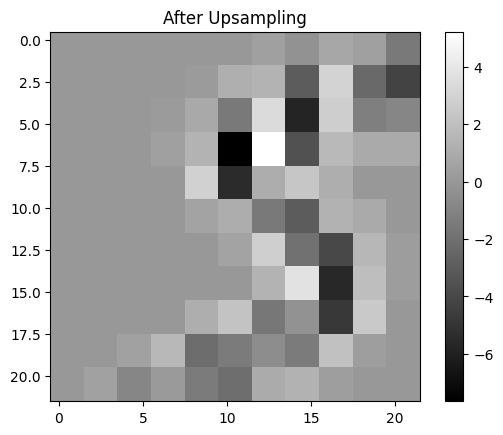

Shape after Upsampling: (22, 22)


In [ ]:
def upsample(image, scale=2):
    """
    Nearest-neighbour upsampling.
    Each pixel value is copied into a (scale x scale) block.
    This doubles the spatial dimensions.
    """
    h, w   = image.shape
    output = np.zeros((h * scale, w * scale))

    for i in range(h):
        for j in range(w):
            # Fill a 2x2 block with the same value
            output[i*scale:(i+1)*scale, j*scale:(j+1)*scale] = image[i, j]

    return output

# Upsample back toward original size
up1 = upsample(conv2)

plt.imshow(up1, cmap='gray')
plt.title("After Upsampling")
plt.colorbar()
plt.show()

# 11x11 -> 22x22
print("Shape after Upsampling:", up1.shape)

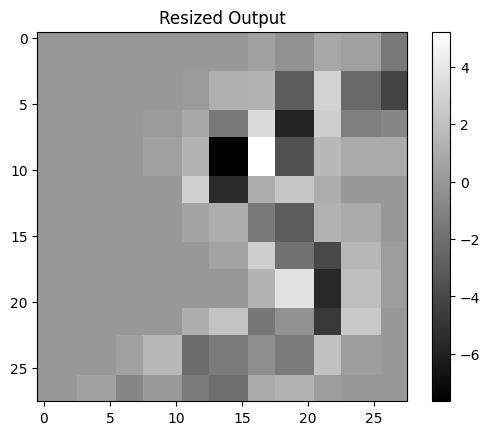

In [ ]:
# The upsampled output is 22x22 but we need 28x28 to match the input
# We use nearest-neighbour interpolation to resize manually
final_output = np.zeros_like(image)

h, w = up1.shape

for i in range(28):
    for j in range(28):
        # Map each output pixel back to the nearest source pixel
        final_output[i, j] = up1[i * h // 28, j * w // 28]

plt.imshow(final_output, cmap='gray')
plt.title("Resized Output")
plt.colorbar()
plt.show()

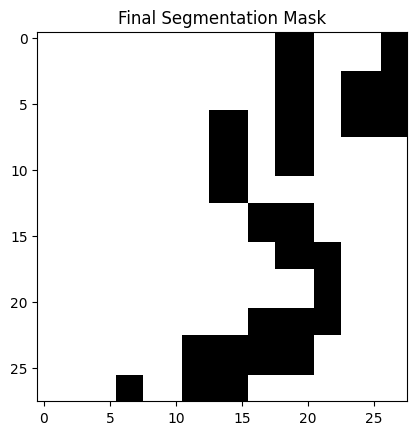

In [ ]:
# Threshold the output to produce a binary segmentation mask
# Pixels above the mean are classified as foreground (digit)
# Pixels below the mean are classified as background
mask = final_output > np.mean(final_output)

plt.imshow(mask, cmap='gray')
plt.title("Final Segmentation Mask")
plt.show()

---
## Part B: FCN with Full Training from Scratch (NumPy only)

Now we build a **trainable FCN** using NumPy — with proper forward and backward passes.

The model has:
- A trainable Convolution layer (4 filters of size 3x3)
- ReLU activation
- Upsampling to restore 28x28
- A pixel-wise classifier (linear layer per pixel)
- Sigmoid + Binary Cross-Entropy loss

We train on 200 MNIST images for 3 epochs, updating filter weights via backpropagation.

The ground truth mask is: pixels > 0 = foreground (digit), pixels = 0 = background.

In [ ]:
(train_images, _), _ = mnist.load_data()

# Normalize pixel values to [0, 1]
train_images = train_images / 255.0

# Create binary segmentation masks:
# Any pixel with value > 0 belongs to the digit (foreground = 1)
# Background pixels are exactly 0 (background = 0)
train_masks = (train_images > 0).astype(float)

# Use a small subset of 200 images for training speed
train_images = train_images[:200]
train_masks  = train_masks[:200]

print("Data shape:", train_images.shape)

Data shape: (200, 28, 28)


In [ ]:
class Conv:
    def __init__(self, num_filters):
        # Initialize num_filters random 3x3 kernels
        # Divide by 9 to keep initial values small (avoid exploding gradients)
        self.filters = np.random.randn(num_filters, 3, 3) / 9

    def forward(self, image):
        self.last_input = image   # save for backprop
        h, w = image.shape

        # Output has shape (h-2, w-2, num_filters) — one feature map per filter
        self.output = np.zeros((h - 2, w - 2, len(self.filters)))

        for f in range(len(self.filters)):
            for i in range(h - 2):
                for j in range(w - 2):
                    patch = image[i:i+3, j:j+3]
                    # Dot product of patch with filter f
                    self.output[i, j, f] = np.sum(patch * self.filters[f])

        return self.output

    def backward(self, dL_dout, lr):
        # Compute gradient of loss with respect to each filter
        dL_dfilters = np.zeros(self.filters.shape)

        for f in range(len(self.filters)):
            for i in range(dL_dout.shape[0]):
                for j in range(dL_dout.shape[1]):
                    patch = self.last_input[i:i+3, j:j+3]
                    # Each filter update = sum of (upstream gradient * patch)
                    dL_dfilters[f] += dL_dout[i, j, f] * patch

        # Update filters using gradient descent
        self.filters -= lr * dL_dfilters

In [ ]:
def relu(x):
    # Apply ReLU element-wise: max(0, x)
    return np.maximum(0, x)

def relu_deriv(x):
    # Derivative of ReLU: 1 where x > 0, else 0
    # Used during backpropagation
    return (x > 0).astype(float)


def upsample(image, target_h, target_w):
    """
    Nearest-neighbour upsampling for 3D feature maps (h, w, channels).
    Maps each output pixel to the nearest source pixel using index scaling.
    """
    h, w, f = image.shape
    out     = np.zeros((target_h, target_w, f))

    for i in range(target_h):
        for j in range(target_w):
            # Safe index mapping — min() prevents out-of-bounds
            src_i = min(int(i * h / target_h), h - 1)
            src_j = min(int(j * w / target_w), w - 1)
            out[i, j] = image[src_i, src_j]

    return out

In [ ]:
class PixelClassifier:
    """
    A simple linear classifier applied independently to each pixel.
    Input: feature vector of size C (number of filters) at one pixel
    Output: a single scalar (logit) passed to sigmoid for probability
    """
    def __init__(self, in_channels):
        # One weight per input channel, initialized small
        self.weights = np.random.randn(in_channels) / in_channels
        self.bias    = 0

    def forward(self, x):
        self.last_input = x           # shape (C,)
        return np.dot(x, self.weights) + self.bias

    def backward(self, dL_dout, lr):
        dL_dout = float(dL_dout)      # ensure scalar

        # Gradient w.r.t weights: upstream_grad * input
        dL_dw = self.last_input * dL_dout

        # Gradient w.r.t input: pass back to upsampled feature map
        dL_dinput = self.weights * dL_dout

        # Update parameters
        self.weights -= lr * dL_dw
        self.bias    -= lr * dL_dout

        return dL_dinput

In [ ]:
def sigmoid(x):
    # Clip to [-50, 50] for numerical stability — avoids overflow in exp
    x = np.clip(x, -50, 50)
    return 1 / (1 + np.exp(-x))


def loss_fn(pred, target):
    # Pixel-wise Binary Cross-Entropy loss
    # Clip predictions to avoid log(0) which is undefined
    pred = np.clip(pred, 1e-7, 1 - 1e-7)
    return -(target * np.log(pred) + (1 - target) * np.log(1 - pred))


def loss_deriv(pred, target):
    # Derivative of BCE + Sigmoid combined — simplifies to (pred - target)
    return (pred - target)

In [ ]:
# 4 trainable 3x3 convolutional filters
conv       = Conv(4)

# Pixel classifier takes a 4-dimensional feature vector (one per filter)
classifier = PixelClassifier(4)

In [ ]:
def train_step(image, mask, lr=0.01):

    # ---- FORWARD PASS ----

    # Conv layer: 28x28 -> 26x26x4
    out      = conv.forward(image)
    out_relu = relu(out)

    # Upsample back to 28x28x4
    up = upsample(out_relu, 28, 28)

    h, w, c = up.shape
    preds   = np.zeros((h, w))

    # Apply pixel classifier at each (i,j) position independently
    for i in range(h):
        for j in range(w):
            preds[i, j] = sigmoid(classifier.forward(up[i, j]))

    # Compute pixel-wise BCE loss averaged over all pixels
    loss = np.mean(loss_fn(preds, mask))

    # ---- BACKWARD PASS ----

    # Gradient of loss w.r.t predictions at each pixel
    grad = loss_deriv(preds, mask)   # shape (28,28)

    # Gradient flowing back through the classifier at each pixel
    grad_classifier = np.zeros_like(up)   # (28,28,4)

    for i in range(h):
        for j in range(w):
            grad_classifier[i, j] = classifier.backward(grad[i, j], lr)

    # Map gradient from upsampled space (28x28) back to conv output space (26x26)
    grad_conv = np.zeros_like(out)   # (26,26,4)

    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            src_i = int(i * h / out.shape[0])
            src_j = int(j * w / out.shape[1])
            grad_conv[i, j] = grad_classifier[src_i, src_j]

    # Apply ReLU derivative — only propagate gradient where ReLU was active
    grad_conv = grad_conv * relu_deriv(out)

    # Update conv filters using backpropagated gradients
    conv.backward(grad_conv, lr)

    return loss

In [ ]:
for epoch in range(3):
    total_loss = 0

    # Shuffle data at start of each epoch to avoid order bias
    indices = np.random.permutation(len(train_images))

    for count, i in enumerate(indices):
        loss       = train_step(train_images[i], train_masks[i])
        total_loss += loss

        # Print progress every 20 steps
        if count % 20 == 0:
            print(f"Epoch {epoch+1} | Step {count} | Loss: {loss:.4f}")

        # Safety check — NaN means learning rate too high or a bug
        if np.isnan(loss):
            print("Loss became NaN — stopping training")
            break

    avg_loss = total_loss / len(train_images)
    print(f"\nEpoch {epoch+1} Completed | Avg Loss: {avg_loss:.4f}\n")

Epoch 1 | Step 0 | Loss: 0.7016
Epoch 1 | Step 20 | Loss: 0.1525
Epoch 1 | Step 40 | Loss: 0.1355
Epoch 1 | Step 60 | Loss: 0.1683
Epoch 1 | Step 80 | Loss: 0.2643
Epoch 1 | Step 100 | Loss: 0.1722
Epoch 1 | Step 120 | Loss: 0.1732
Epoch 1 | Step 140 | Loss: 0.1919
Epoch 1 | Step 160 | Loss: 0.1345
Epoch 1 | Step 180 | Loss: 0.0967

Epoch 1 Completed | Avg Loss: 0.1501

Epoch 2 | Step 0 | Loss: 0.1566
Epoch 2 | Step 20 | Loss: 0.1123
Epoch 2 | Step 40 | Loss: 0.1624
Epoch 2 | Step 60 | Loss: 0.1583
Epoch 2 | Step 80 | Loss: 0.1142
Epoch 2 | Step 100 | Loss: 0.0914
Epoch 2 | Step 120 | Loss: 0.1189
Epoch 2 | Step 140 | Loss: 0.2033
Epoch 2 | Step 160 | Loss: 0.1670
Epoch 2 | Step 180 | Loss: 0.1382

Epoch 2 Completed | Avg Loss: 0.1329

Epoch 3 | Step 0 | Loss: 0.1390
Epoch 3 | Step 20 | Loss: 0.1699
Epoch 3 | Step 40 | Loss: 0.1392
Epoch 3 | Step 60 | Loss: 0.1622
Epoch 3 | Step 80 | Loss: 0.1723
Epoch 3 | Step 100 | Loss: 0.1492
Epoch 3 | Step 120 | Loss: 0.0657
Epoch 3 | Step 140 | L

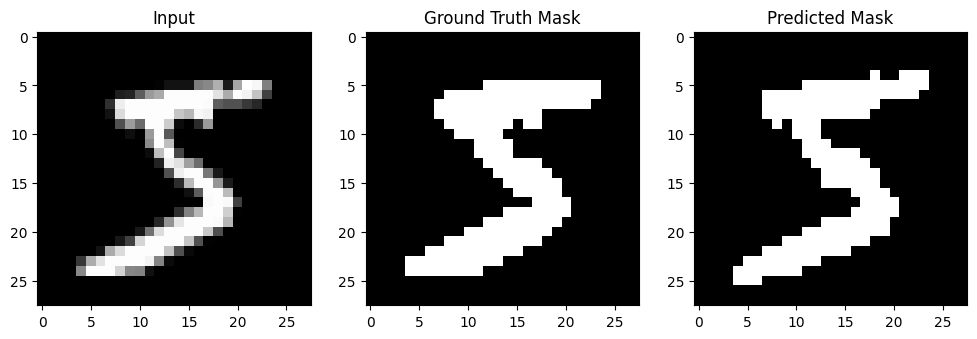

In [ ]:
# Run the trained model on the first training image
test_img = train_images[0]

out  = conv.forward(test_img)
out  = relu(out)
up   = upsample(out, 28, 28)

h, w, c = up.shape
pred    = np.zeros((h, w))

for i in range(h):
    for j in range(w):
        pred[i, j] = sigmoid(classifier.forward(up[i, j]))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Input")
plt.imshow(test_img, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Ground Truth Mask")
plt.imshow(train_masks[0], cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Predicted Mask")
plt.imshow(pred > 0.5, cmap='gray')

plt.show()

---
## Part C: Full FCN using TensorFlow/Keras

Now we build and train a proper FCN using the Keras deep learning library.

The architecture follows the Encoder-Bottleneck-Decoder structure:

Encoder:
- Conv2D (16 filters) + ReLU + MaxPooling -> 28x28 becomes 14x14
- Conv2D (32 filters) + ReLU + MaxPooling -> 14x14 becomes 7x7

Bottleneck:
- Conv2D (64 filters) + ReLU -> stays 7x7 but learns rich features

Decoder:
- UpSampling2D -> 7x7 becomes 14x14
- Conv2D (32 filters) + ReLU
- UpSampling2D -> 14x14 becomes 28x28
- Conv2D (16 filters) + ReLU

Output:
- Conv2D (1 filter, 1x1 kernel, Sigmoid) -> pixel-wise probability map 28x28x1

Loss: Binary Cross-Entropy (each pixel independently classified)
Optimizer: Adam

In [ ]:
# TensorFlow — deep learning framework
import tensorflow as tf
from tensorflow import keras

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# Create binary segmentation masks:
# Digit pixels (value > 0) = 1, background pixels (value = 0) = 0
y_train = (x_train > 0).astype(np.float32)
y_test  = (x_test  > 0).astype(np.float32)

# Add channel dimension: (N, 28, 28) -> (N, 28, 28, 1)
# Keras Conv2D expects 4D input: (batch, height, width, channels)
x_train = x_train[..., np.newaxis]
y_train = y_train[..., np.newaxis]

x_test  = x_test[..., np.newaxis]
y_test  = y_test[..., np.newaxis]

print("Input shape:", x_train.shape)

Input shape: (60000, 28, 28, 1)


In [ ]:
# Define FCN architecture using Keras functional API
inputs = keras.Input(shape=(28, 28, 1))

# --- Encoder ---
# First conv block: 16 filters, 3x3 kernel, same padding keeps size at 28x28
x = keras.layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
# MaxPooling reduces 28x28 -> 14x14
x = keras.layers.MaxPooling2D()(x)

# Second conv block: 32 filters
x = keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)
# MaxPooling reduces 14x14 -> 7x7
x = keras.layers.MaxPooling2D()(x)

# --- Bottleneck ---
# Deepest part: 64 filters — learns the most abstract features
x = keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)

# --- Decoder ---
# UpSampling restores 7x7 -> 14x14
x = keras.layers.UpSampling2D()(x)
x = keras.layers.Conv2D(32, 3, activation='relu', padding='same')(x)

# UpSampling restores 14x14 -> 28x28
x = keras.layers.UpSampling2D()(x)
x = keras.layers.Conv2D(16, 3, activation='relu', padding='same')(x)

# --- Output Layer ---
# 1x1 Conv with Sigmoid: collapses 16 channels to 1, gives probability per pixel
outputs = keras.layers.Conv2D(1, 1, activation='sigmoid')(x)

# Build model
model = keras.Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,401 (181.25 KB)

 Trainable params: 46,401 (181.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile with Adam optimizer and Binary Cross-Entropy loss
# Binary Cross-Entropy is correct here — each pixel is an independent binary classification
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train for 3 epochs
# validation_split=0.1 uses 10% of training data to monitor overfitting
history = model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 171s 100ms/step - accuracy: 0.9789 - loss: 0.0524 - val_accuracy: 0.9856 - val_loss: 0.0351
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 170s 101ms/step - accuracy: 0.9880 - loss: 0.0298 - val_accuracy: 0.9896 - val_loss: 0.0260
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 173s 103ms/step - accuracy: 0.9912 - loss: 0.0224 - val_accuracy: 0.9925 - val_loss: 0.0198


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step


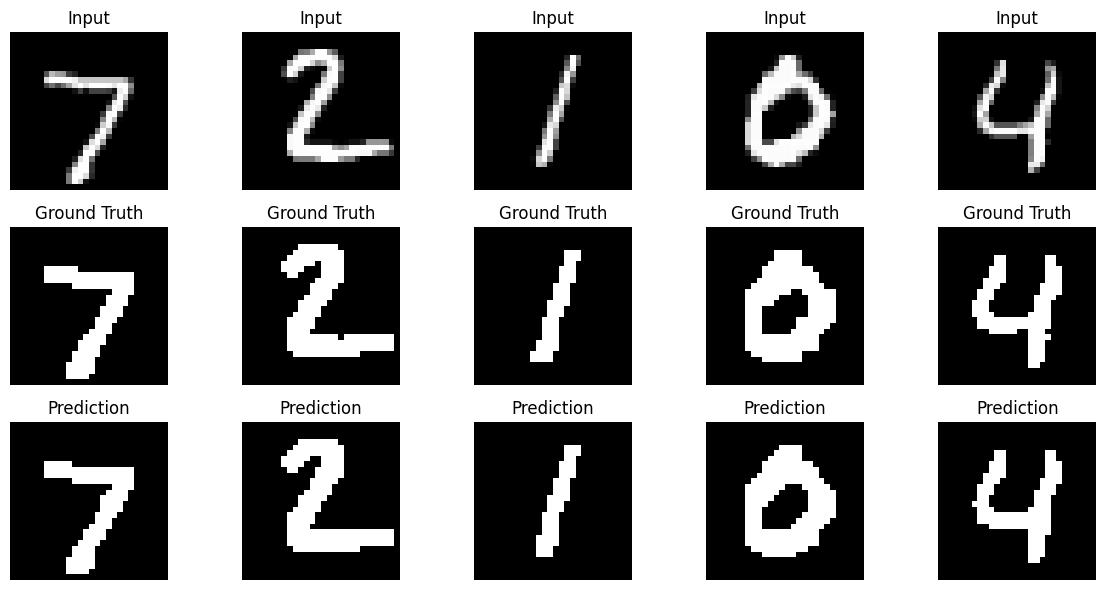

In [ ]:
# Run predictions on first 5 test images
preds = model.predict(x_test[:5])

plt.figure(figsize=(12, 6))

for i in range(5):

    # Row 1: Input images
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title("Input")
    plt.axis('off')

    # Row 2: Ground truth masks
    plt.subplot(3, 5, i + 6)
    plt.imshow(y_test[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    # Row 3: Model predictions (threshold at 0.5)
    plt.subplot(3, 5, i + 11)
    plt.imshow(preds[i].squeeze() > 0.5, cmap='gray')
    plt.title("Prediction")
    plt.axis('off')

plt.tight_layout()
plt.show()

---
### Conclusion

In this experiment, we implemented Semantic Segmentation using a Fully Convolutional Network (FCN) in two ways:

**Part A — FCN Concept from Scratch (No Training):**
We manually walked through Convolution, ReLU, Max Pooling, a second Convolution, Upsampling, resize to original size, and thresholding — on a single MNIST digit image. This demonstrated exactly what each layer does to the feature map at every step.

**Part B — FCN with Training from Scratch (NumPy):**
We built a trainable FCN using NumPy classes with proper forward and backward passes. The trainable Conv layer learned 4 filters via gradient descent. The PixelClassifier independently classified each pixel using a linear layer. Training ran for 3 epochs on 200 images, and the model learned to segment digit pixels from background.

**Part C — FCN using TensorFlow/Keras:**
We built a proper Encoder-Bottleneck-Decoder FCN using Keras. The encoder compressed 28x28 to 7x7 while learning rich features. The decoder upsampled back to 28x28. The final 1x1 convolution with Sigmoid produced a pixel-wise probability mask. The model was trained with Binary Cross-Entropy loss and Adam optimizer, achieving strong pixel-level segmentation of MNIST digits.

Key Insight: The fundamental difference between FCN and standard CNN is that FCN preserves spatial information throughout — it never flattens the feature maps. This allows it to produce a segmentation mask the same size as the input image, making it suitable for pixel-level tasks.